# CSCE 40103 Module 2 - Lab 1
## PHISHING URL CLASSIFICATION WITH DATA CLEANING, FEATURE PREPARATION, CROSS-VALIDATION, AND TUNING

**Dataset used:** PhiUSIIL_Phishing_URL_Dataset


## 1. Setup



In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("PhiUSIIL_Phishing_URL_Dataset.csv")

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## 2. Load the Dataset

Load the PhiUSIIL dataset into a DataFrame named df.


In [2]:
def load_phishing_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df


df = load_phishing_dataset()
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Loading local CSV file: PhiUSIIL_Phishing_URL_Dataset.csv
Dataset loaded successfully.
Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


## 3: Inspect the Dataset

Display the dataset size, column names, and data types

In [3]:
print("Rows and columns:", df.shape)
print("Column names:")
print(df.columns)
print("Dataset information:")
df.info()

Rows and columns: (235795, 56)
Column names:
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'N

## 4: Check Missing Values and Duplicate Rows

Check whether the dataset contains missing values and duplicate rows.

In [4]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Series([], dtype: int64)
Number of duplicate rows: 0


## 5: Inspect the Target Variable

Display class counts and percentages, then create a class distribution plo

Class counts:
label
1    134850
0    100945
Name: count, dtype: int64
Class percentages:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


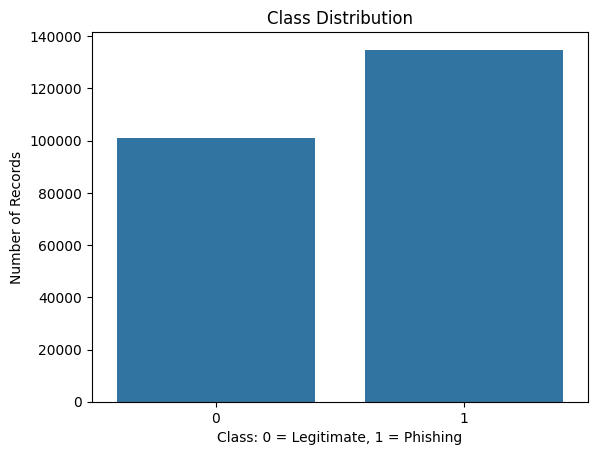

In [5]:
class_counts = df["label"].value_counts()
class_percentages = df["label"].value_counts(normalize=True) * 100
print("Class counts:")
print(class_counts)
print("Class percentages:")
print(class_percentages.round(2))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Class: 0 = Legitimate, 1 = Phishing")
plt.ylabel("Number of Records")
plt.show()

## 6: Select Useful Features

Use the provided candidate list and keep only the columns that exist in the dataset.

In [6]:
candidate_features = [
"URLLength",
"DomainLength",
"NoOfSubDomain",
"NoOfLettersInURL",
"NoOfDegitsInURL",
"NoOfOtherSpecialCharsInURL",
"IsHTTPS",
"NoOfExternalRef",
"LineOfCode",
"LargestLineLength"
]
selected_features = []
for col in candidate_features:
    if col in df.columns:
        selected_features.append(col)
print("Selected features:")
print(selected_features)

Selected features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength']


## 7: Explore Numeric Feature Distributions

Create histograms for important numeric features

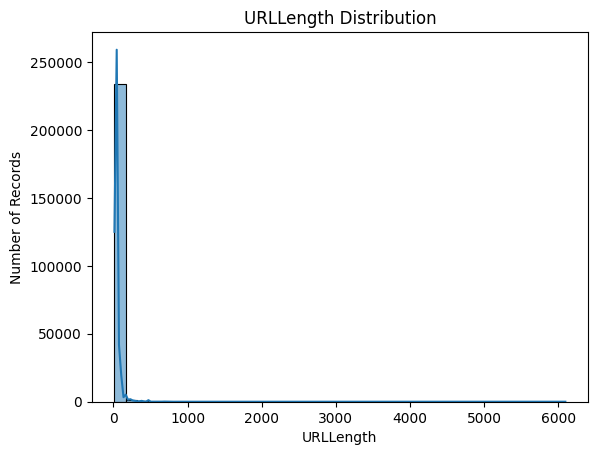

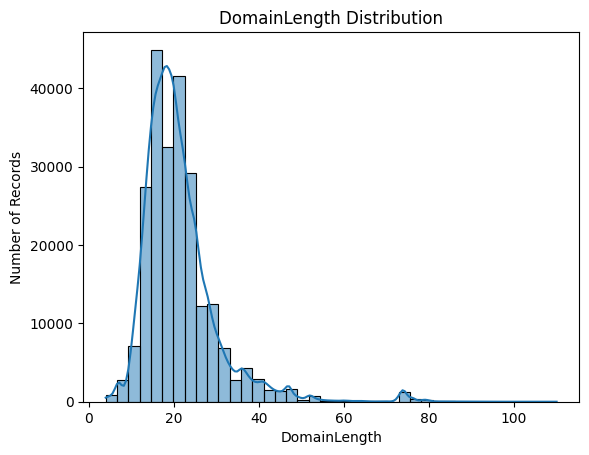

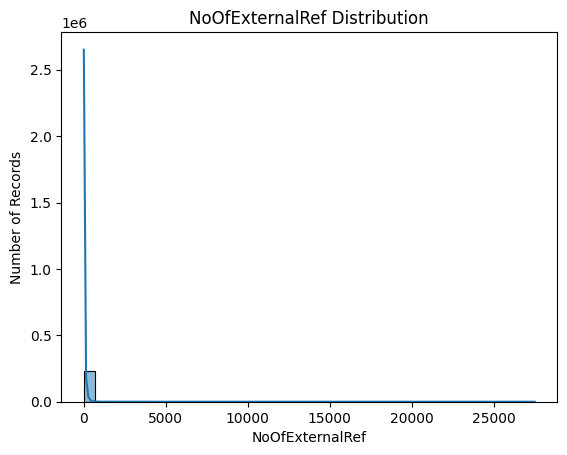

In [7]:
features_to_plot = ["URLLength", "DomainLength", "NoOfExternalRef"]
for feature in features_to_plot:
    if feature in df.columns:
        sns.histplot(data=df, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

## 8: Create Simple Engineered Features
Create log-transformed versions of skewed numeric features.

In [8]:
work_df = df.copy()
if "URLLength" in work_df.columns:
    work_df["log_URLLength"] = np.log1p(work_df["URLLength"])
if "NoOfExternalRef" in work_df.columns:
    work_df["log_NoOfExternalRef"] = np.log1p(work_df["NoOfExternalRef"])
work_df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label,log_URLLength,log_NoOfExternalRef
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1,3.465736,4.828314
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1,3.178054,5.384495
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1,3.401197,1.791759
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1,3.295837,3.465736
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1,3.526361,4.454347


## 9: Compare Raw and Log-Transformed Values
Create raw and log-transformed histograms for URLLength.

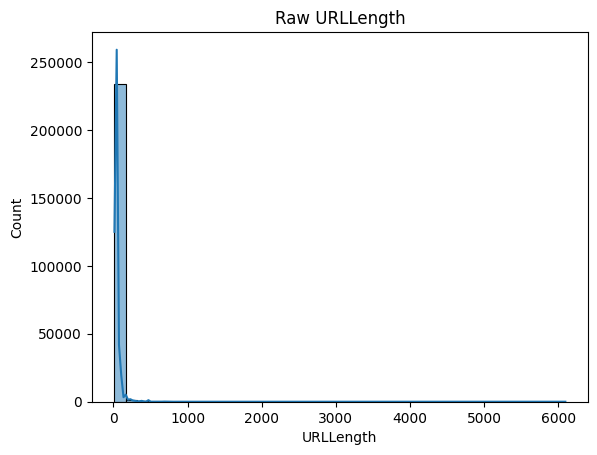

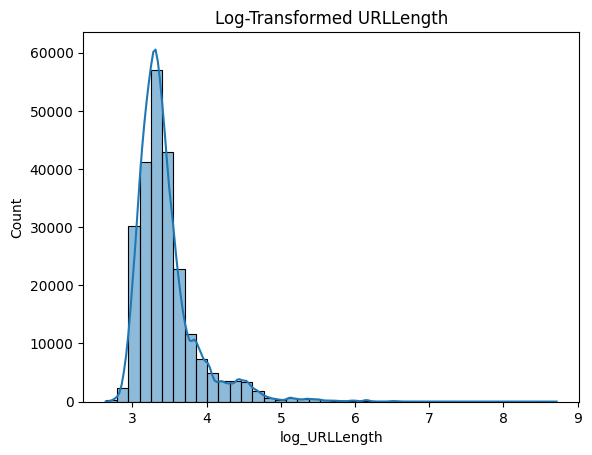

In [9]:
if "URLLength" in work_df.columns:
    sns.histplot(data=work_df, x="URLLength", bins=40, kde=True)
    plt.title("Raw URLLength")
    plt.show()
    sns.histplot(data=work_df, x="log_URLLength", bins=40, kde=True)
    plt.title("Log-Transformed URLLength")
    plt.show()

## 10: Update the Feature List
Add the engineered features to the selected feature list.

In [10]:
final_features = selected_features.copy()
if "log_URLLength" in work_df.columns:
    final_features.append("log_URLLength")
if "log_NoOfExternalRef" in work_df.columns:
    final_features.append("log_NoOfExternalRef")
print("Final features:")
print(final_features)

Final features:
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'NoOfExternalRef', 'LineOfCode', 'LargestLineLength', 'log_URLLength', 'log_NoOfExternalRef']


## 11: Correlation Analysis
Create a correlation heatmap using the final numeric features and the label

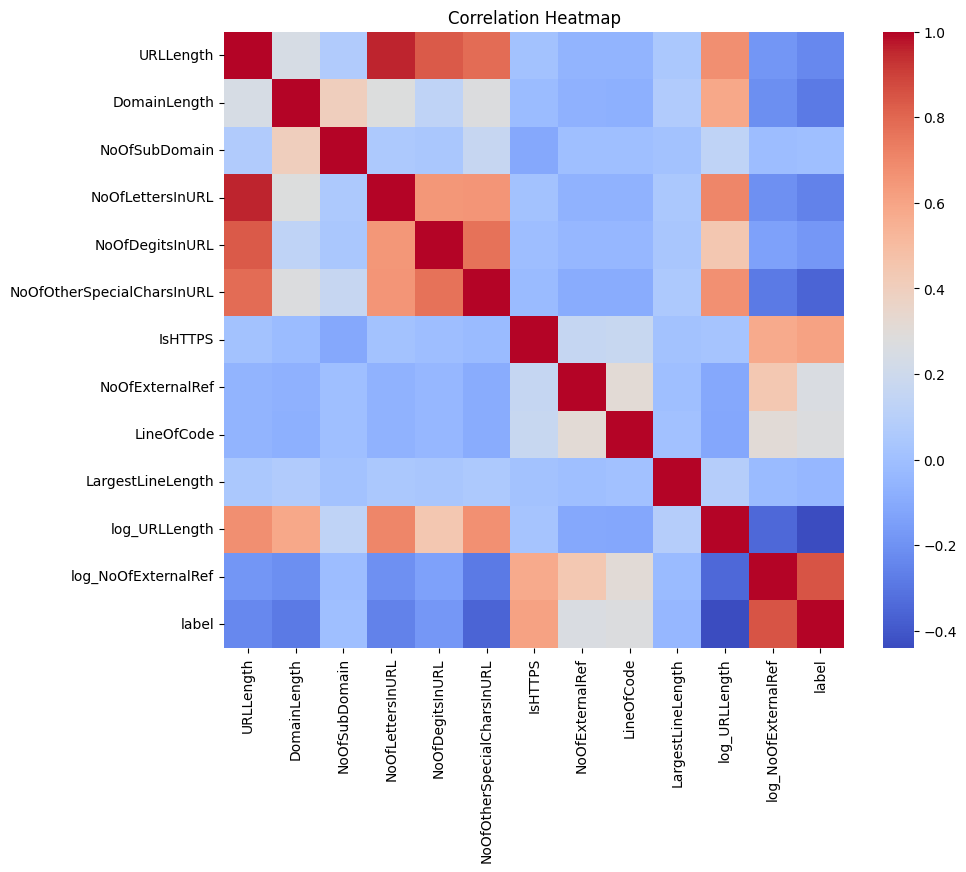

In [11]:
corr = work_df[final_features + ["label"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 12: Create X and y

Create the feature matrix X and target vector y

In [12]:
X = work_df[final_features]
y = work_df["label"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235795, 12)
y shape: (235795,)


## 13: Train-Test Split

Split the data into training and testing sets. Use stratify=y to preserve class proportions

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
stratify=y,
random_state=40103
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Testing class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training rows: 176846
Testing rows: 58949
Training class distribution:
label
1    0.572
0    0.428
Name: proportion, dtype: float64
Testing class distribution:
label
1    0.572
0    0.428
Name: proportion, dtype: float64


## 14: Fill Missing Values

Use the training median to fill missing values. Use the same training median for the test set.

In [14]:
train_medians = X_train.median()
X_train_clean = X_train.fillna(train_medians)
X_test_clean = X_test.fillna(train_medians)
print("Missing values in X_train_clean:", X_train_clean.isnull().sum().sum())
print("Missing values in X_test_clean:", X_test_clean.isnull().sum().sum())

Missing values in X_train_clean: 0
Missing values in X_test_clean: 0


## 15: Scale Numeric Features

Scale the features using StandardScaler. Fit the scaler only on the training data.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (176846, 12)
Scaled testing shape: (58949, 12)


## 16: Train Logistic Regression

Create, train, and evaluate a Logistic Regression model.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



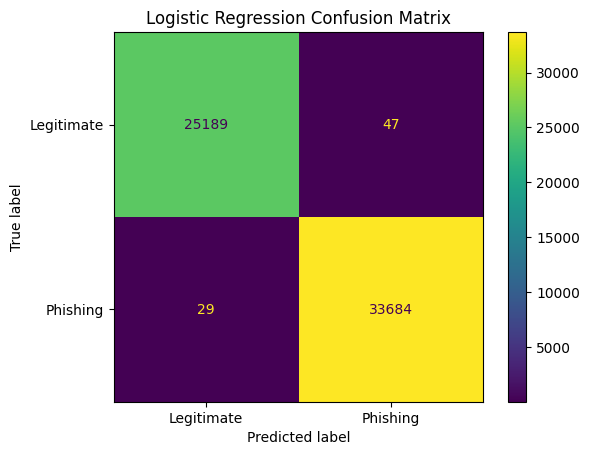

In [16]:
log_model = LogisticRegression(
max_iter=1000,
class_weight="balanced",
random_state=40103
)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
print(classification_report(y_test, log_pred, zero_division=0))
log_cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(
confusion_matrix=log_cm,
display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 17: Train Decision Tree

Create, train, and evaluate a Decision Tree model.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



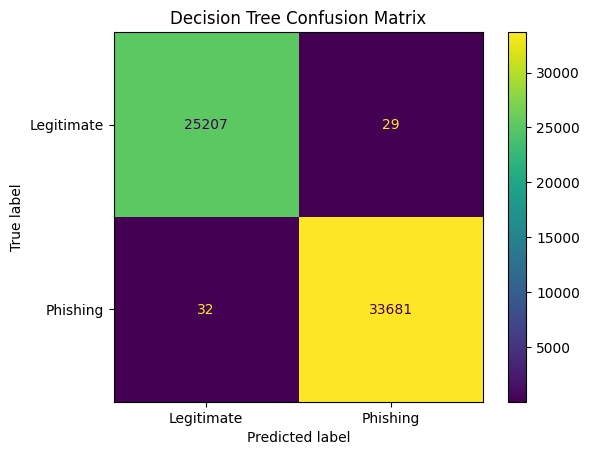

In [17]:
tree_model = DecisionTreeClassifier(
random_state=40103,
class_weight="balanced"
)
tree_model.fit(X_train_clean, y_train)
tree_pred = tree_model.predict(X_test_clean)
print(classification_report(y_test, tree_pred, zero_division=0))
tree_cm = confusion_matrix(y_test, tree_pred)
disp = ConfusionMatrixDisplay(
confusion_matrix=tree_cm,
display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 18: Create a Metric Summary Table

Create a function to compute model metrics and display a comparison table.
get_metrics()

In [18]:
def get_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
results = [
    get_metrics("Logistic Regression", y_test, log_pred),
    get_metrics("Decision Tree", y_test, tree_pred)
]
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.998711,0.998607,0.999140,0.998873
1,Decision Tree,0.998965,0.999140,0.999051,0.999095


## 19: Stratified k-Fold Cross-Validation

Use stratified 5-fold cross-validation to compare the two models more reliably.

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40103
)
scoring = ["accuracy", "precision", "recall", "f1"]
X_clean = X.fillna(X.median())
X_scaled = scaler.fit_transform(X_clean)
log_cv = cross_validate(
 log_model,
 X_scaled,
 y,
 cv=cv,
 scoring=scoring
)
tree_cv = cross_validate(
    tree_model,
    X_clean,
    y,
    cv=cv,
    scoring=scoring
)
cv_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": log_cv["test_accuracy"].mean(),
        "Precision": log_cv["test_precision"].mean(),
        "Recall": log_cv["test_recall"].mean(),
        "F1": log_cv["test_f1"].mean()
    },
    {
        "Model": "Decision Tree",
        "Accuracy": tree_cv["test_accuracy"].mean(),
        "Precision": tree_cv["test_precision"].mean(),
        "Recall": tree_cv["test_recall"].mean(),
        "F1": tree_cv["test_f1"].mean()
    }
])
cv_summary

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.998745,0.998703,0.999103,0.998903
1,Decision Tree,0.998931,0.999036,0.999095,0.999066


## 20: Hyperparameter Tuning for Decision Tree
Tune only the Decision Tree model. Random Forest is not used in this lab.

In [20]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=40103,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1"
)
tree_grid.fit(X_train_clean, y_train)
print("Best parameters:")
print(tree_grid.best_params_)
print("Best cross-validation F1:")
print(tree_grid.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1:
0.9989866323357453


## 21: Evaluate the Tuned Decision Tree
Use the best Decision Tree model to predict the test set.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25236
           1       1.00      1.00      1.00     33713

    accuracy                           1.00     58949
   macro avg       1.00      1.00      1.00     58949
weighted avg       1.00      1.00      1.00     58949



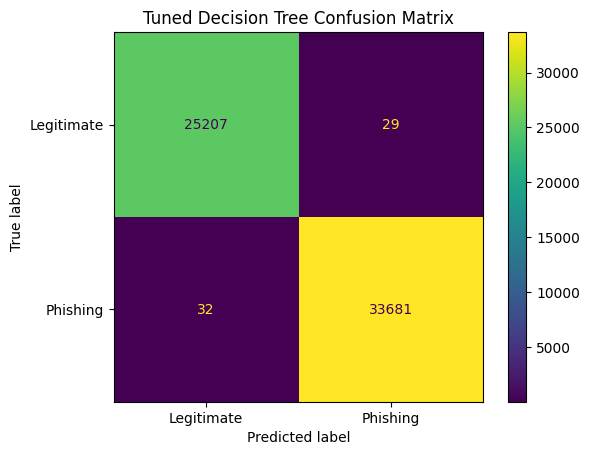

In [21]:
best_tree = tree_grid.best_estimator_
tuned_tree_pred = best_tree.predict(X_test_clean)
print(classification_report(y_test, tuned_tree_pred, zero_division=0))
tuned_cm = confusion_matrix(y_test, tuned_tree_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Legitimate", "Phishing"]
)
disp.plot(values_format="d")
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

## 22: Final Comparison Table
Create a final table comparing all three model versions

In [22]:
final_results = [
    get_metrics("Logistic Regression", y_test, log_pred),
    get_metrics("Decision Tree", y_test, tree_pred),
    get_metrics("Tuned Decision Tree", y_test, tuned_tree_pred)
]
final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.998711,0.998607,0.999140,0.998873
1,Decision Tree,0.998965,0.999140,0.999051,0.999095
2,Tuned Decision Tree,0.998965,0.999140,0.999051,0.999095
